# Notebook 02 — RFM Feature Engineering

Notebook này tính toán 3 chỉ số RFM từ dữ liệu giao dịch đã làm sạch:

| Chỉ số | Ý nghĩa | Cách tính |
|---|---|---|
| **Recency (R)** | Gần đây nhất khách hàng mua hàng | Số ngày từ lần mua cuối đến ngày tham chiếu |
| **Frequency (F)** | Tần suất mua hàng | Số hóa đơn khác nhau |
| **Monetary (M)** | Giá trị tiền tệ | Tổng doanh thu từ khách hàng |

**Đầu vào:** `data/processed/clean_transactions.csv`  
**Đầu ra:** `data/processed/rfm_table.csv`

## 1. Setup

In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.processors.csv_processor import CSVProcessor
from src.models.calculators.rfm_calculator import RFMCalculator

CLEAN_PATH = '../data/processed/clean_transactions.csv'
RFM_PATH   = '../data/processed/rfm_table.csv'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Đọc dữ liệu đã làm sạch

In [2]:
processor = CSVProcessor(input_path=CLEAN_PATH)
df = processor.read()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f'Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột')
print(f'Số khách hàng: {df["CustomerID"].nunique():,}')
print(f'Giai đoạn: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
display(df.head(3))

Kích thước: 344,433 dòng x 9 cột
Số khách hàng: 3,920
Giai đoạn: 2010-12-01 → 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00


## 3. Tính RFM

**Ngày tham chiếu (reference date):** ngày sau ngày giao dịch cuối cùng 1 ngày.  
Cách này đảm bảo khách mua ngày cuối có Recency = 1 (không phải 0).

In [3]:
calculator = RFMCalculator()
rfm = calculator.build_rfm_table(df)

reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Ngày tham chiếu: {reference_date.date()}')
print(f'Số khách hàng trong RFM table: {len(rfm):,}')
display(rfm.head())

Ngày tham chiếu: 2011-12-10
Số khách hàng trong RFM table: 3,920


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12747,2,11,4196.01
2,12748,1,209,32448.84
3,12749,4,5,4090.88
4,12820,3,4,942.34


In [4]:
print('Thống kê mô tả RFM:')
display(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

Thống kê mô tả RFM:


,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00
mean,92.21,4.25,1849.64
std,99.53,7.20,7470.34
min,1.00,1.00,3.75
25%,18.00,1.00,295.26
50%,51.00,2.00,638.06
75%,143.00,5.00,1562.58
max,374.00,209.00,259657.30


## 4. Phân phối của R, F, M

Dữ liệu RFM thường bị **lệch phải (right-skewed)** — phần lớn khách hàng có giá trị thấp, một ít khách có giá trị rất cao.  
Cần quan sát phân phối trước khi đưa vào mô hình.

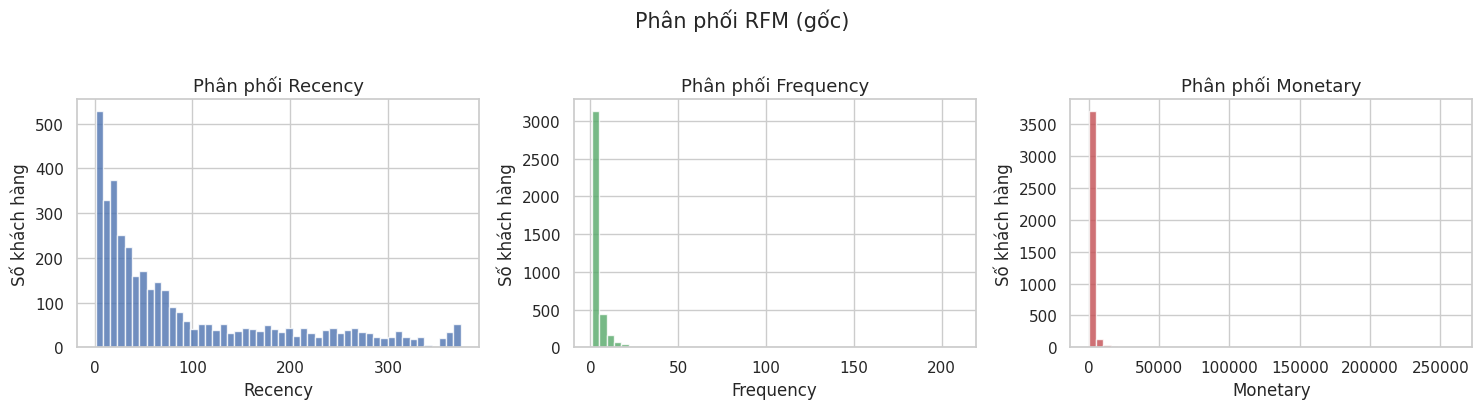

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric, color in zip(axes, metrics, colors):
    ax.hist(rfm[metric], bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Phân phối {metric}', fontsize=13)
    ax.set_xlabel(metric)
    ax.set_ylabel('Số khách hàng')

plt.suptitle('Phân phối RFM (gốc)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 4.1 Sau khi biến đổi log (log1p)

`log1p(x) = log(x + 1)` giúp giảm độ lệch và làm phân phối gần với chuẩn hơn — cần thiết trước khi dùng K-means.

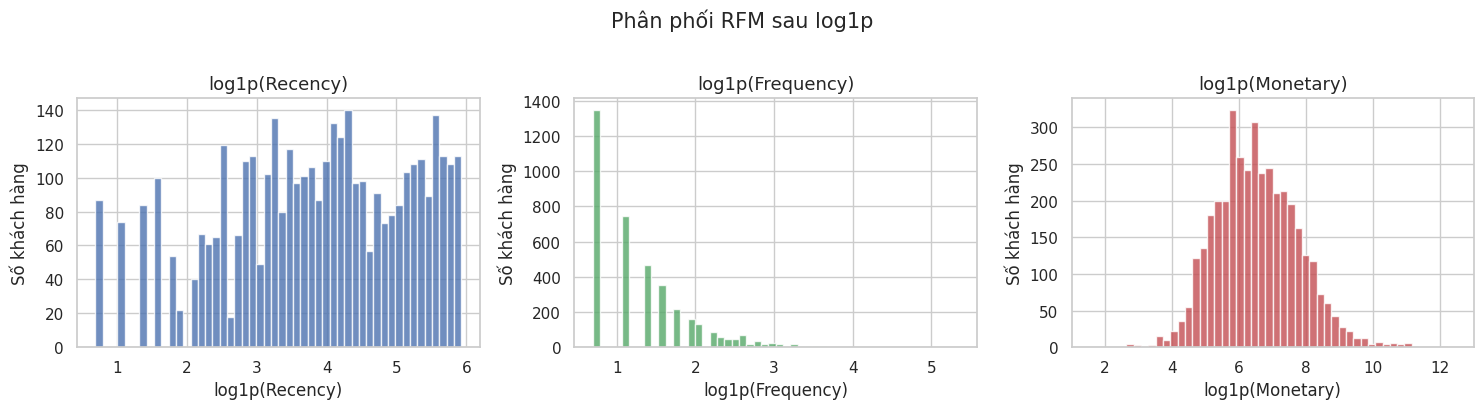

In [6]:
rfm_log = rfm[metrics].apply(np.log1p)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, color in zip(axes, metrics, colors):
    ax.hist(rfm_log[metric], bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'log1p({metric})', fontsize=13)
    ax.set_xlabel(f'log1p({metric})')
    ax.set_ylabel('Số khách hàng')

plt.suptitle('Phân phối RFM sau log1p', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 5. Tương quan giữa R, F, M

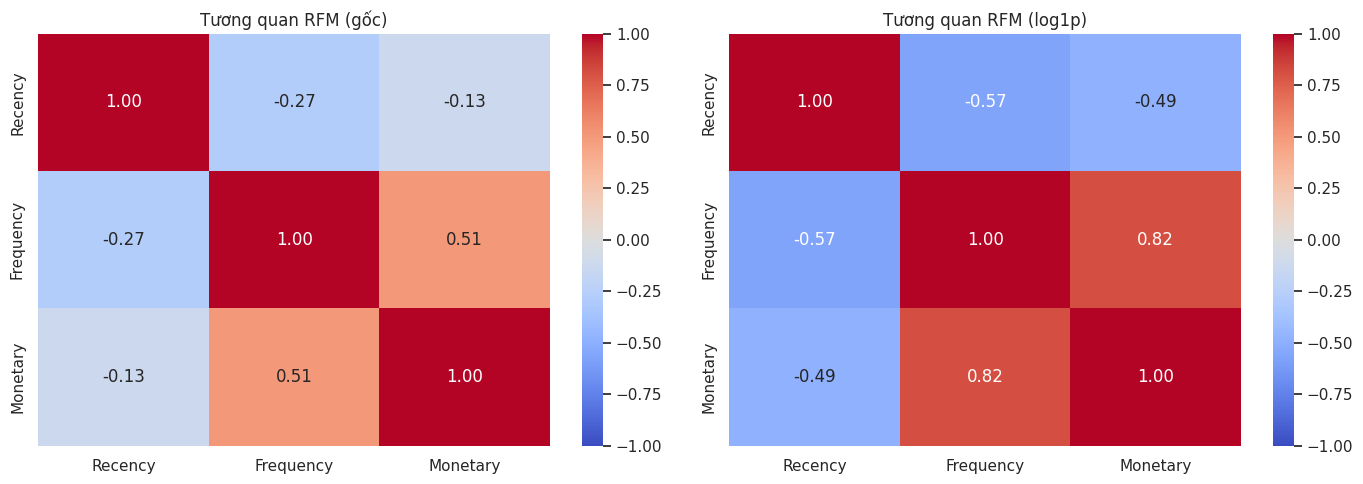

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_raw = rfm[metrics].corr()
corr_log = rfm_log.corr()

sns.heatmap(corr_raw, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Tương quan RFM (gốc)')

sns.heatmap(corr_log, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Tương quan RFM (log1p)')

plt.tight_layout()
plt.show()

## 6. RFM Scoring (Quintile)

Gán điểm 1–5 cho mỗi chỉ số bằng phương pháp **quintile (phân vị)**:
- **R_Score**: 5 = mua gần nhất, 1 = mua lâu nhất
- **F_Score**: 5 = tần suất cao nhất
- **M_Score**: 5 = chi tiêu nhiều nhất
- **RFM_Score**: tổng 3 điểm (3–15)

In [8]:
rfm = calculator.score_rfm(rfm, n_bins=5)

print(f'RFM Score — min: {rfm["RFM_Score"].min()}, max: {rfm["RFM_Score"].max()}')
display(rfm.head(10))

RFM Score — min: 3, max: 14


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,7
1,12747,2,11,4196.01,5,4,5,14
2,12748,1,209,32448.84,5,4,5,14
3,12749,4,5,4090.88,5,3,5,13
4,12820,3,4,942.34,5,3,4,12
5,12821,214,1,92.72,1,1,1,3
6,12822,71,2,948.88,3,1,4,8
7,12823,75,5,1759.50,2,3,4,9
8,12824,60,1,397.12,3,1,2,6
9,12826,3,7,1474.72,5,4,4,13


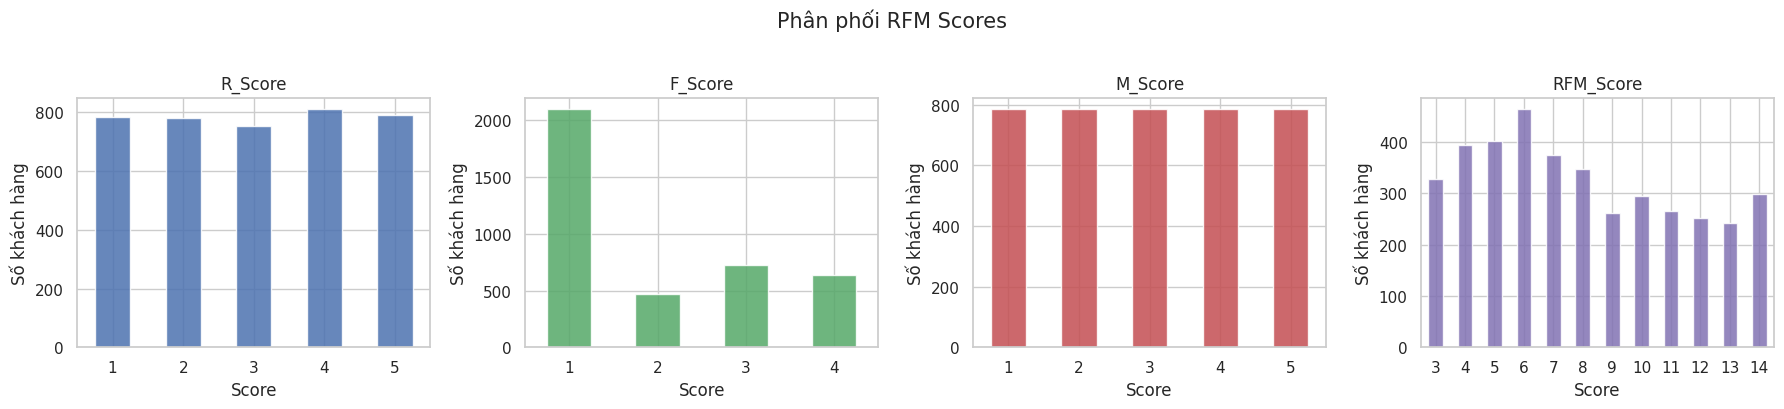

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
score_cols = ['R_Score', 'F_Score', 'M_Score', 'RFM_Score']
score_colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B3']

for ax, col, color in zip(axes, score_cols, score_colors):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Score')
    ax.set_ylabel('Số khách hàng')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Phân phối RFM Scores', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Xuất RFM Table

In [10]:
rfm.to_csv(RFM_PATH, index=False)
print(f'Đã lưu RFM table tại: {RFM_PATH}')
print(f'Kích thước: {rfm.shape[0]:,} khách hàng x {rfm.shape[1]} cột')
print(f'Cột: {list(rfm.columns)}')

Đã lưu RFM table tại: ../data/processed/rfm_table.csv
Kích thước: 3,920 khách hàng x 8 cột
Cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']
